# Probability Distributions: Hands-On Coding Activity
###**CSIT212 — Quantitative Methods**
###Based on: *Probability Distributions: Implementation* (Contreras)

---

## Instructions

1. This activity mirrors the lesson notebook **"Probability Distributions: Implementation."** Each task below only gives you the **problem, the formula, and hints** — you write the code yourself. Re-open the lesson notebook if you need to recall how a similar function was structured.
2. Fill in every cell marked `# TODO`. Do **not** delete the markdown hints — leave them as your reference (and as part of your submission).
3. Run every cell before submitting — a notebook with errors will be marked down. Restart the kernel and **Run All** at the end to confirm nothing breaks.
4. You may use `numpy` for arrays/ranges and `matplotlib`/`seaborn` for plotting, exactly as in the lesson. Unless a task explicitly says otherwise, **do not** import `math.factorial`, `math.exp`, or `scipy.stats` shortcuts — the point of this activity is to build the logic yourself, the way the lesson did.
5. **Filename:** rename this notebook to
   ```
   prob_dist_implement_<lastname>.ipynb
   ```
   (all lowercase, your surname only — e.g. `prob_dist_implement_contreras.ipynb`).
6. **Submission:** upload the renamed `.ipynb` file to the assignment post on **MS Teams**. Do not submit a Colab/Drive link — the actual file.
7. **AI Usage Disclosure:** a required section is included at the very end of this notebook. If you used any AI tool at any point while completing this activity, you must disclose it there. See that section for the exact format expected. Leaving it blank is treated as a declaration that no AI tool was used — do not leave it blank if that isn't true.

**Full Name: Hertz Lenin C. Miscreola**

**Course-Section: CSIT212-F1**

**Date Submitted: 10/4/2026**


In [53]:
# Setup — run this first
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

---
## 1. Counting Principle

### Task 1.1 — Factorial (build it yourself)

$$n! = n \times (n-1) \times (n-2) \times \dots \times 1, \qquad 0! = 1$$

Write `factorial(n)` **without** using `math.factorial` — a loop is enough.

**Hints**
- What should the running product start at *before* the loop multiplies anything into it?
- Your loop only needs to start at `2` — multiplying by `1` and `0!`'s base case don't need extra lines.
- Guard against negative `n` the same way the lesson did (`raise ValueError`).

In [54]:
def factorial(n):
    # TODO: implement factorial from scratch (loop-based, no math.factorial)
  if n < 0:
    raise ValueError("Factorial doesn't work for negative numbers.")

  res = 1
  for i in range(2, n + 1):
    res *= i

  return res

# Test — do not edit, this should print 0! through 5!
for i in range(6):
    print(f"{i}! = {factorial(i)}")

0! = 1
1! = 1
2! = 2
3! = 6
4! = 24
5! = 120


### Task 1.2 — Permutation (reuse your `factorial`)

$$_{n}P_{r} = \frac{n!}{(n-r)!}$$

**Hints**
- Call the `factorial` function you just wrote — don't recompute factorials by hand.
- Use integer division (`//`) so you get a whole number, not a float.
- What should happen if `r > n`?

In [55]:
def permutation(n, r):
    # TODO: implement nPr using your factorial() function
    return (factorial(n) / factorial(n - r))

# Test
print(f"P(8,3) = {permutation(8, 3)}")   # expected: 336

P(8,3) = 336.0


### Task 1.3 — Combination (reuse your `factorial`)

$$_{n}C_{r} = \binom{n}{r} = \frac{n!}{r!\,(n-r)!}$$

**Hints**
- Same idea as permutation, but you divide out the ordering of the chosen items too.

In [56]:
def combination(n, r):
    # TODO: implement nCr using your factorial() function
    return (factorial(n) / (factorial(r) * factorial(n - r)))

# Test
print(f"C(10,3) = {combination(10, 3)}")   # expected: 120

C(10,3) = 120.0


### Task 1.4 — Word Problem: Permutation & Combination

A university's IT club has **15 members**: **9 Software Engineering (SE)** majors and **6 Network Engineering (NE)** majors.

For a hackathon, **5 members** will be selected from the 15. The 5 selected members will then be assigned to **five different stations**:

- Backend
- Frontend
- Database
- QA/Testing
- Presenter

If exactly **3 SE majors and 2 NE majors** must be selected, what is the probability that **Miguel**, an SE major, is selected **and** assigned as **Presenter**?

**Hints**
- Break it into the same two pieces the lesson example used: (a) total ways to *select* the group, and (b) total ways to *assign roles* to a selected group — multiply them for total outcomes.
- For the favorable count: Miguel is already fixed as one SE slot and as Presenter. How many SE members are left to choose from for the remaining SE slot(s)? How many ways can the *other four* people be assigned to the *remaining four* roles?
- `combination()` for selecting people, `permutation()` for assigning roles — same pattern as the lesson's Ana example.
- Probability = favorable outcomes ÷ total outcomes.

In [57]:
# TODO: solve the word problem above.
# Suggested structure (fill in the blanks / rename as you like):
n = 15
n_se = 9
n_ne = 6
n_st = 5

r_se = 3
r_ne = 2

total_selection = combination(n_se, r_se) * combination(n_ne, r_ne)
total_roles = permutation(n_st, n_st)
total_outcomes = total_selection * total_roles

remaining_se = combination(n_se - 1, r_se - 1)
ne_selection = combination(n_ne, r_ne)
remaining_roles = permutation(n_st - 1, n_st - 1)
favorable_outcomes = remaining_se * ne_selection * remaining_roles

probability = favorable_outcomes / total_outcomes
print(f"Probability: {probability:0.4f}")

Probability: 0.0667


---
## 2. Discrete Probability Distributions

$$E(X) = \sum_i x_i \, P(x_i) \qquad E(X^2) = \sum_i x_i^2 \, P(x_i)$$

$$\text{Var}(X) = E(X^2) - \big[E(X)\big]^2 \qquad \sigma = \text{SD}(X) = \sqrt{\text{Var}(X)}$$

### Task 2.1 — `discrete_stats()`

**Hints**
- You'll need to pair up each `x` with its matching probability — `zip()` is useful here, just like in the lesson.
- Compute `E(X)` and `E(X^2)` first as separate sums, then combine them for variance.
- Add the same sanity check the lesson used: probabilities should sum to (approximately) 1.

In [58]:
def discrete_stats(x_values, probabilities):
    # TODO: return E(X), E(X^2), Var(X), SD(X)
    expected_value = sum(x * p for x, p in zip(x_values, probabilities))
    expected_square = sum(x**2 * p for x, p in zip(x_values, probabilities))
    variance = expected_square - expected_value**2
    std_deviation = variance**0.5
    return expected_value, expected_square, variance, std_deviation

### Task 2.2 — Apply it

Scenario: the number of Wi-Fi disconnections during a 1-hour lab class at CIT-U follows this distribution:

| X (disconnections) | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| P(X) | 0.15 | 0.35 | 0.30 | 0.15 | 0.05 |

Compute E(X), E(X²), Var(X), SD(X), **and** plot the PMF as a bar chart with a vertical line marking E(X) — same style as the lesson's jeepney-breakdown example.

**Hints**
- Reuse `discrete_stats()` from Task 2.1.
- For the plot: `plt.bar()` for the bars, `plt.axvline()` for the E(X) line, and don't forget a title and axis labels.

E(X)	= 1.60
E(X^2)	= 3.70
Var(X)	= 1.14
SD(X)	= 1.07


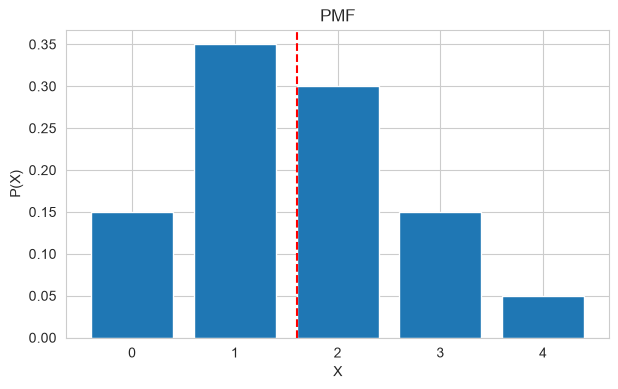

In [59]:
# TODO: define x_values and probabilities for the Wi-Fi scenario,
# call discrete_stats(), print the four results, then plot the PMF.
x_values = [0, 1, 2, 3, 4]
probabilities = [0.15, 0.35, 0.30, 0.15, 0.05]

expected_value, expected_square, variance, std_deviation = discrete_stats(x_values, probabilities)

print(f"E(X)\t= {expected_value:.2f}")
print(f"E(X^2)\t= {expected_square:.2f}")
print(f"Var(X)\t= {variance:.2f}")
print(f"SD(X)\t= {std_deviation:.2f}")

plt.axvline(expected_value, color='red', linestyle='--', label=f'E(X) = {expected_value:.2f}')

plt.bar(x_values, probabilities)
plt.xlabel('X')
plt.ylabel('P(X)')
plt.title('PMF')
plt.show()

---
## 3. Binomial Distribution

$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k} \qquad E(X) = np \qquad \text{Var}(X) = np(1-p)$$

### Task 3.1 — `binomial_pmf()`

**Hints**
- Reuse your own `combination()` — no `scipy.stats.binom`.

In [60]:
def binomial_pmf(k, n, p):
    # TODO: implement the binomial PMF formula using combination()
    return combination(n, k) * p**k * (1 - p)**(n - k)

### Task 3.2 — Apply it

Scenario: A True/False quiz has **8 items**. A student who has not studied guesses every item, each with a **50%** chance of being correct.

1. Compute `P(X = k)` for every `k` from 0 to 8.
2. Print the mean (`np`) and variance (`np(1-p)`).
3. Confirm the probabilities sum to 1.
4. Plot the PMF as a bar chart with the mean marked, same style as the lesson.

**Hints**
- Build a list comprehension over `k_values = list(range(n + 1))`, same pattern as the lesson's quiz example.

Mean: 4.00
Variance: 2.00


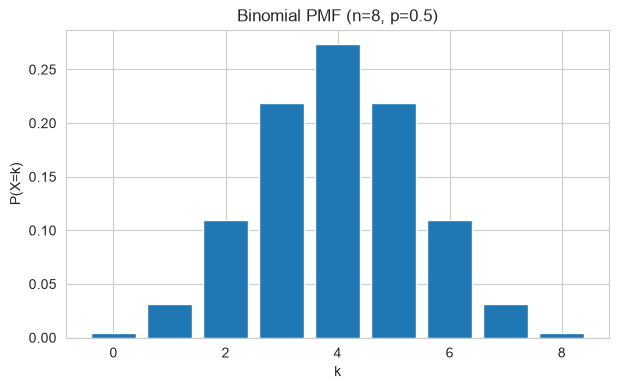

In [61]:
# TODO: n, p = 8, 0.5 — compute binom_probs, mean, variance, verify sum ≈ 1, then plot.
n = 8
p = 0.5
binomial_probs = [binomial_pmf(k, n, p) for k in range(n + 1)]
mean = n * p
variance = n * p * (1 - p)

print(f"Mean: {mean:.2f}")
print(f"Variance: {variance:.2f}")

plt.bar(range(n + 1), binomial_probs)
plt.xlabel('k')
plt.ylabel('P(X=k)')
plt.title(f'Binomial PMF (n={n}, p={p})')
plt.show()

---
## 4. Poisson Distribution

$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!} \qquad E(X) = \text{Var}(X) = \lambda$$

### Task 4.1 — `poisson_pmf()`

**Hints**
- You may use `math.exp` and `math.factorial` for this one (as the lesson notebook itself did) — or, for an optional challenge, rebuild `e^{-\lambda}$ yourself with a Taylor-series `exp_approx()` and reuse your own `factorial()` from Task 1.1 instead.

In [62]:
import math

def poisson_pmf(k, lam):
    # TODO: implement the Poisson PMF formula
    return (lam**k * math.exp(-lam)) / factorial(k)

### Task 4.2 — Apply it

Scenario: A university printing station receives an average of **6 print-job errors per day**.

1. Compute `P(X = k)` for `k = 0` to `14`.
2. Confirm mean = variance = λ.
3. Plot the PMF as a bar chart with λ marked, same style as the lesson's help-desk example.
4. Separately, what is `P(X = 6)` — the probability of *exactly* the average number of errors? Is it the *highest* probability in the distribution? Why might that not always be true for small λ? (Answer briefly in a markdown cell.)

Mean: 6 == Variance: 6 == Lam: 6


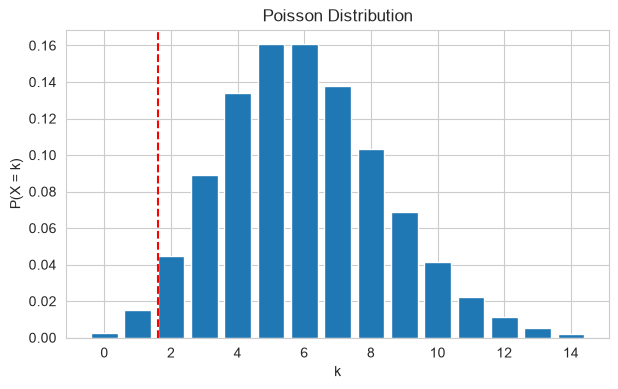

In [63]:
# TODO: lam = 6 — compute poisson_probs for k = 0..14, verify mean/variance, then plot.
lam = 6
poisson_probs = [poisson_pmf(k, lam) for k in range(15)]

ks = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
mean = math.ceil(sum(k * p for k, p in zip(ks, poisson_probs)))
variance = math.ceil(sum((k - mean)**2 * p for k, p in zip(ks, poisson_probs)))

print(f"Mean: {mean} == Variance: {variance} == Lam: {lam}")

plt.bar(ks, poisson_probs)
plt.axvline(expected_value, color='red', linestyle='--', label=f'E(X) = {expected_value:.2f}')
plt.xlabel("k")
plt.ylabel("P(X = k)")
plt.title("Poisson Distribution")
plt.show()


In [64]:
# TODO: compute and print P(X = 6) specifically.
px_6 = poisson_pmf(6, lam)
print(f"P(X=6) = {px_6:.4f}")


P(X=6) = 0.1606


*Your brief answer to the "why" question above:*
> .
>
> The probability of exactly the average number of errors is P(x = 6) = 0.1606.
> P(x = 6) is one highest probability, but it isn't the only highest probability.
> P(x = 6) shares the same result as P(x = 5) with a 0.1606 as a result.
> 
> The mean is not automatically the single most likely outcome nor does it mean hitting the exact average is common.
> Even though 6 is the average number of errors per day, P(x = 6) is only just about 16.06%
> It's not much, having exactly 6 errors on any given day happens less than 1 out of 6 times.
> Just because a value is considered the average, doesn't mean it happens most of the time.
> 84% of the other days will have different amount of errors.
> 
> For small λ, the single most likely outcome is almost always 0.
> When the average rates are small (λ < 1) 0 errors is by far the single most likely outcome on any single day, even though the average is above 0.  
> 
> .

---
## 5. Bayes' Theorem

$$P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)} \qquad \text{where } P(B) = P(B\mid A)P(A) + P(B\mid \lnot A)P(\lnot A)$$

### Task 5.1 — `bayes_theorem()`

**Hints**
- Compute `P(not A)` first, then `P(B)` using the law of total probability, then plug into the main formula.
- Return both `P(A|B)` and `P(B)` — the lesson's version does this so you can inspect the denominator too.

In [65]:
def bayes_theorem(p_a, p_b_given_a, p_b_given_not_a):
    # TODO: return P(A | B) and P(B)
    p_b = p_b_given_a * p_a + p_b_given_not_a * (1 - p_a)
    p_a_given_b = (p_b_given_a * p_a) / p_b

    return p_a_given_b, p_b

### Task 5.2 — Apply it

Scenario: An anti-plagiarism system flags submitted papers.

- 3% of all submitted papers are actually plagiarized: `P(A) = 0.03`
- If a paper **is** plagiarized, the system flags it correctly 90% of the time: `P(B|A) = 0.90`
- If a paper is **not** plagiarized, the system still flags it (a false positive) 4% of the time: `P(B|¬A) = 0.04`

Compute `P(A|B)` — given that a paper was flagged, what is the probability it is *actually* plagiarized? Print your result and, in a markdown cell, briefly explain in your own words why this number is lower than most people expect.

In [66]:
# TODO: compute p_condition_given_flag and p_flag using bayes_theorem(), then print both.
p_a_given_b, p_b = bayes_theorem(0.03, 0.90, 0.04)
print(f"P(B) = {p_b:.4f}")
print(f"P(A | B) = {p_a_given_b:.4f}")

P(B) = 0.0658
P(A | B) = 0.4103


*Your brief explanation:*

> .
> 
> Given that a paper was flagged, the probability of it actually being plagiarized is 41.03 % (P(A|B) = 0.4103).
>
> The number looks lower than most people expect because the rate of papers actually being plagiarized is only 3% which is very small, and the system catches them 90% of the time.
>
> People will see that 90% and think that there's going to be a lot of plagiarism going on but that 90% only means how efficient the system is catching the 3% of plagiarized papers.
>
> Let's there were 1000 papers that were submitted, around 30 of them are plagiarized, the system catches 27 of those.
>
> Then 970 of those papers are clean which the system flags 39 papers incorrectly.
>
> Out of 66 total papers flagged, only 39 of them are false alarms while only 27 are the real deal.
>
>Because clean papers take up the majority of the submissions, even a small 4% error rate makes more false alarms than catching the paigarism.
>
> That's why flagged papers are still more likely to be a false positive than true cases, and why I think is the cause of people's misconceptions.
> 
> .

---
## 6. PDF & CDF — Conceptual Check

Answer the following in your own words (no code needed, just markdown text below each question).

**Q1.** For a continuous random variable, why is $f(x)$ — the PDF value at a single point — **not** itself a probability?

**Q2.** If $F(x)$ is the CDF of some continuous distribution, what do $F(-\infty)$ and $F(\infty)$ equal, and why?

**Q3.** If you already have a distribution's CDF function, how would you compute $P(a \le X \le b)$ using it?

**A1:**
> .
> 
> PDF f(x), which stands for Probability Density Function, from the name itself it means that it calculates the probability density.
> 
> When we say density it's the amount of things crowding around that area, in this case it's the relative height or concentration at x, not the probability itself.
>
> Also from what I understood, continuous means that there are infinite precise numbers within them, that means you can't exactly get that one single point.
>
> It's like tring to stop a timer at exactly 2.00000000 down to a tee, you need to set a range from 1.9 to 2.1 to get the real probability.
>
> .

**A2:**
> .
> 
> CDF F(x), which stands for Cumulative Distribution Function, is a function that gives the probability that a random variable X takes a value less than or equal to x.
>
> I like to think of it as a progress bar, that's going from 0% (0.0000) to 100% (1.0000) 
>
> $F(-\infty) = 0$ because at negative infinity, you are the beginning of everything, no outcomes existed yet.
>
> $f(\infty) = 1$ because at positive infinity, you've reached the end at 100% which is 1.0000.
> 
> .

**A3:**
> .
> 
> I would compute as such P(a <= X <= b) = F(b) - F(a)
>
> So in P(a <= X <= b) going back to the progress bar analogy, from 0% to 100%:
>
> F(b) gives me the total accumulated probability from 0% all the way to b.
>
> F(a) does the same, giving me the total accumulated probability from 0% all the way to a.
>
> If we are looking for the middle point which is X, we take the full total up to b and chop off (subtract) everything up to a, hence:
>
> P(a <= X <= b) F(b) - F(a)
> 
> .

---
## 7. Uniform Distribution

$$f(x) = \begin{cases} \dfrac{1}{b-a} & a \le x \le b \\ 0 & \text{otherwise} \end{cases}
\qquad
F(x) = \begin{cases} 0 & x < a \\ \dfrac{x-a}{b-a} & a \le x \le b \\ 1 & x > b \end{cases}$$

Mean $= \dfrac{a+b}{2}$, Variance $= \dfrac{(b-a)^2}{12}$

### Task 7.1 — `uniform_pdf()` and `uniform_cdf()`

**Hints**
- `uniform_pdf` needs a conditional: return `0` outside `[a, b]`.
- `uniform_cdf` needs three cases: below `a`, between `a` and `b`, above `b` — same structure as the lesson.

In [67]:
def uniform_pdf(x, a, b):
    if a <= x <= b:
        return 1 / (b - a)
    
    return 0

def uniform_cdf(x, a, b):
    if x < a:
        return 0
    elif x > b:
        return 1
    
    return (x - a) / (b - a)

### Task 7.2 — Apply it

Scenario: The time (in minutes) it takes a printing station to process a document is uniformly distributed between **2 and 12 minutes**.

1. Compute the mean and variance.
2. Compute `P(X <= 5)`, `P(5 <= X <= 8)`, and `P(X > 8)` using your `uniform_cdf`.
3. Plot the PDF and CDF side by side, same layout as the lesson (`plt.subplots(1, 2, ...)`).

**Hints**
- `P(5 <= X <= 8) = uniform_cdf(8, a, b) - uniform_cdf(5, a, b)`.

Mean: 7.00
Variance: 8.33
P(X < 5) = 0.3000
P(5 <= X <= 8) = 0.3000
P(X > 8) = 0.4000


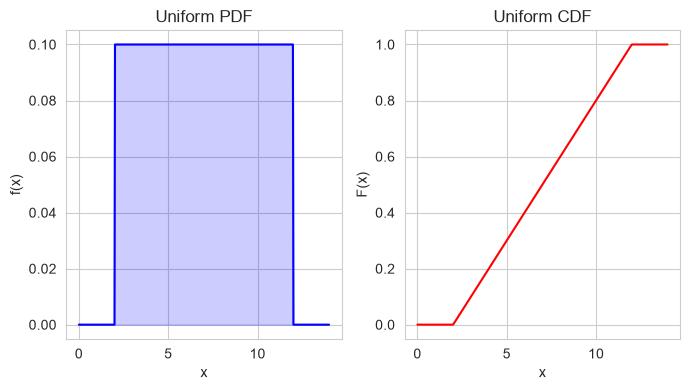

In [68]:
# TODO: a, b = 2, 12 — compute mean, variance, the three probabilities, and plot PDF + CDF.
a, b = 2, 12
mean = (a + b) / 2
variance = ((b - a) ** 2) / 12

print(f"Mean: {mean:.2f}")
print(f"Variance: {variance:.2f}")

p_less_than_5 = uniform_cdf(5, a, b)
p_between_5_and_8 = uniform_cdf(8, a, b) - uniform_cdf(5, a, b)
p_greater_than_8 = 1 - uniform_cdf(8, a, b)

print(f"P(X < 5) = {p_less_than_5:.4f}")
print(f"P(5 <= X <= 8) = {p_between_5_and_8:.4f}")
print(f"P(X > 8) = {p_greater_than_8:.4f}")

x_vals = np.linspace(0, 14, 500)
pdf_vals = [uniform_pdf(x, a, b) for x in x_vals]
cdf_vals = [uniform_cdf(x, a, b) for x in x_vals]

fig, (ax1, ax2) = plt.subplots(1, 2)

ax1.plot(x_vals, pdf_vals, label='PDF', color='blue')
ax1.fill_between(x_vals, pdf_vals, alpha=0.2, color='blue')
ax1.set_title('Uniform PDF')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')

ax2.plot(x_vals, cdf_vals, label='CDF', color='red')
ax2.set_title('Uniform CDF')
ax2.set_xlabel('x')
ax2.set_ylabel('F(x)')

plt.tight_layout()
plt.show()


---
## 8. Normal Distribution (CDF via Simpson's Rule)

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \, e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

The Normal CDF has **no closed form**, so we integrate the PDF numerically using **Simpson's Rule**:

$$\int_{a}^{b} f(x)\,dx \approx \frac{h}{3}\Big[f(x_0) + 4\!\!\sum_{\text{odd } i} f(x_i) + 2\!\!\sum_{\text{even } i} f(x_i) + f(x_n)\Big], \quad h = \frac{b-a}{n}$$

### Task 8.1 — `normal_pdf()`

**Hints**
- You may use `math.exp` and `math.sqrt` here, same as the lesson.

In [69]:
import math

def normal_pdf(x, mu=0, sigma=1):
    # TODO: implement the normal PDF formula
    c = 1 / (sigma * math.sqrt(2 * math.pi))
    e = -((x - mu) ** 2) / (2 * sigma ** 2)
    return c * math.exp(e)
    

### Task 8.2 — `simpsons_rule()`

**Hints**
- Make sure `n` is forced to even (add 1 if it's odd) before computing `h`.
- The endpoints `f(a)` and `f(b)` get weight 1; odd-indexed interior points get weight 4; even-indexed interior points get weight 2.
- A loop from `1` to `n-1` (inclusive) covers all the interior points.

In [70]:
def simpsons_rule(f, a, b, n=1000):
    # TODO: implement Simpson's Rule numerical integration
    if n % 2 != 0:
        n += 1

    h = (b - a) / n
    s = f(a) + f(b)

    for i in range(1, n):
        x = a + i * h
        if i % 2 == 0:
            s += 2 * f(x)
        else:
            s += 4 * f(x)

    return s * h / 3

### Task 8.3 — `normal_cdf()` (built on your Simpson's Rule)

**Hints**
- "Negative infinity" isn't literal here — the lesson used `mu - 10 * sigma` as a practical stand-in for the far left tail. Do the same.
- You'll integrate `normal_pdf` from that lower bound up to `x`.

In [71]:
def normal_cdf(x, mu=0, sigma=1, lower_bound=None, n=1000):
    # TODO: implement using simpsons_rule() and normal_pdf()
    if lower_bound is None:
        lower_bound = mu - 10.0 * sigma

    if x <= lower_bound:
        return 0.0

    f = lambda t: normal_pdf(t, mu, sigma)

    cdf_val = simpsons_rule(f, lower_bound, x, n)

    return max(0.0, min(1.0, cdf_val))

    

# Sanity check — do not edit. These should be close to 0.5000, 0.9750, 0.0250
print(f"F(0)     ≈ {normal_cdf(0):.4f}   (expected ~0.5000)")
print(f"F(1.96)  ≈ {normal_cdf(1.96):.4f}   (expected ~0.9750)")
print(f"F(-1.96) ≈ {normal_cdf(-1.96):.4f}   (expected ~0.0250)")

F(0)     ≈ 0.5000   (expected ~0.5000)
F(1.96)  ≈ 0.9750   (expected ~0.9750)
F(-1.96) ≈ 0.0250   (expected ~0.0250)


### Task 8.4 — Apply it

Scenario: A CSIT212 quiz score is Normal-distributed with **μ = 70, σ = 10**.

1. What fraction of students scored **below 55**?
2. What fraction scored **above 85**?
3. Plot the PDF with vertical lines marking μ and μ+σ, same style as the lesson.

**Hints**
- "Above 85" = `1 - normal_cdf(85, mu, sigma)`.

P(X < 55) = 0.0668
P(X > 85) = 0.0668


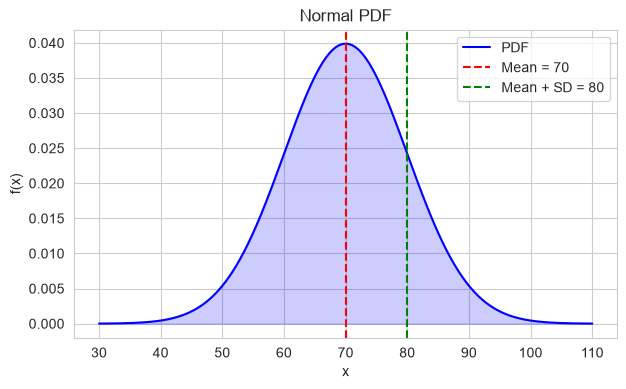

In [72]:
# TODO: mu, sigma = 70, 10 — compute the two probabilities and plot the PDF.
mu = 70
sigma = 10

n_1 = normal_cdf(55, mu, sigma)
n_2 = 1 - normal_cdf(85, mu, sigma)

print(f"P(X < 55) = {n_1:.4f}")
print(f"P(X > 85) = {n_2:.4f}")

x_vals = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 500)
pdf_vals = [normal_pdf(x, mu, sigma) for x in x_vals]

plt.plot(x_vals, pdf_vals, label='PDF', color='blue')
plt.fill_between(x_vals, pdf_vals, alpha=0.2, color='blue')

plt.axvline(x=mu, color='red', linestyle='--', label=f'Mean = {mu}')
plt.axvline(x=mu + sigma, color='green', linestyle='--', label=f'Mean + SD = {mu + sigma}')

plt.title('Normal PDF')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()


---
## 9. Exponential Distribution

$$f(x) = \lambda e^{-\lambda x}, \quad x \ge 0 \qquad F(x) = 1 - e^{-\lambda x}, \quad x \ge 0$$

Mean $= \dfrac{1}{\lambda}$, Variance $= \dfrac{1}{\lambda^2}$

### Task 9.1 — `exponential_pdf()` and `exponential_cdf()`

**Hints**
- Both functions should return `0` for `x < 0` — the distribution only exists for non-negative values.

In [73]:
def exponential_pdf(x, lam):
    # TODO
    return lam * math.exp(-lam * x) if x >= 0 else 0

def exponential_cdf(x, lam):
    # TODO
    return 1 - math.exp(-lam * x) if x >= 0 else 0

### Task 9.2 — Apply it

Scenario: The time between successive log-ins to a university's LMS averages **1 login every 3 minutes** during peak hours.

1. Compute the mean, variance, and standard deviation.
2. Compute `P(wait <= 2 minutes)`.
3. Plot the PDF with vertical lines marking the mean and mean+SD, same style as the lesson.

**Hints**
- `lam = 1 / 3` here (rate = 1 / average interval).

Mean: 3.00
Variance: 9.00
Standard Deviation: 3.00
P(wait <= 2) = 0.4866


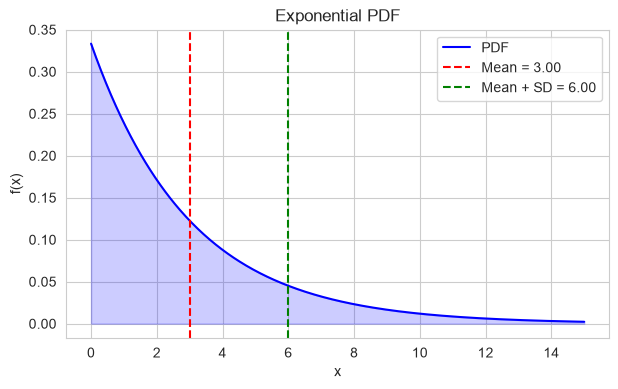

In [74]:
# TODO: lam = 1/3 — compute mean, variance, SD, P(wait <= 2), and plot the PDF.
lam = 1 / 3
mean = 1 / lam
variance = 1 / (lam ** 2)
sd = math.sqrt(variance)

print(f"Mean: {mean:.2f}")
print(f"Variance: {variance:.2f}")
print(f"Standard Deviation: {sd:.2f}")


n_2 = exponential_cdf(2, lam)
print(f"P(wait <= 2) = {n_2:.4f}")

x_vals = np.linspace(0, 15, 500)
pdf_vals = [exponential_pdf(x, lam) for x in x_vals]

plt.plot(x_vals, pdf_vals, label='PDF', color='blue')
plt.fill_between(x_vals, pdf_vals, alpha=0.2, color='blue')

plt.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.2f}')
plt.axvline(mean + sd, color='green', linestyle='--', label=f'Mean + SD = {mean + sd:.2f}')

plt.title('Exponential PDF')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.show()


---
## AI Usage Disclosure *(required)*

If you used **any** AI tool (e.g., ChatGPT, Claude, Gemini, GitHub Copilot, or similar) at **any point** while completing this activity — to explain a concept, debug an error, suggest code, check your work, etc. — you must disclose it here. This is not a penalty; using AI tools responsibly is fine, but you must be transparent about it.

If you did **not** use any AI tool, write "No AI tools were used" below and skip the rest of this section.

**For each tool you used, provide:**
- **Tool name & version** (e.g., ChatGPT-5, Claude Sonnet 4.6, GitHub Copilot)
- **Date(s) used**
- **What you used it for** (e.g., "explained why my Simpson's Rule loop was off by one," "debugged a TypeError in Task 3.2") — be specific per task, not just "helped with the notebook"
- **What you changed or learned as a result**, in your own words

*Suggested citation format (APA-style, for your reference list if your course requires one):*
> OpenAI. (2026). *ChatGPT* (May 2026 version) [Large language model]. https://chat.openai.com

---

**Your disclosure:**

Tool name & version: Google Gemini (October 2026 version)

Date(s) used:
- October 5, 2026

What I used it for:
- Tasks 8.1 - 8.3 (Normal Distribution & Simpson's Rule): Helped implementing the functions `normal_pdf`, `simpsons_rule`, and `normal_cdf`.

What I changed or learned as a result:
- Unwrapping the process of Simpson's Rule and Normal CDF and learned how to implement it through code.